<!-- AI-og-helse: colab-kontrakt v1 -->

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/arvidl/AI-og-helse/blob/main/uke05-agentisk-ai/01_chatbot_workflow_agent.ipynb)

## Colab-kjøring

- **Anbefalt runtime:** CPU
- **Forventet kjøretid:** 15-30 min
- **Datamønster:** `synthetic-or-inline`

**Krav før kjøring:**
- API: ikke nødvendig med mindre notebooken ber om det
- Data: syntetisk case/materiale
- GPU: ikke nødvendig

**Felles konvensjon:** Kjør setup-cellen rett under først. I Colab hentes hemmeligheter fra **Secrets** med `userdata.get(...)`; lokalt brukes miljøvariabler eller `.env`.

Kjør cellene ovenfra og ned. Setup-cellen installerer bare ekstra pakker når notebooken åpnes i Colab.


In [4]:
# AI-og-helse: Colab bootstrap v1
import importlib.util
import os
import subprocess
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
NOTEBOOK_PACKAGES = []
COLAB_DATA_MODE = 'synthetic-or-inline'


def _has_import(import_name: str) -> bool:
    return importlib.util.find_spec(import_name) is not None


def ensure_packages(packages=NOTEBOOK_PACKAGES):
    """Install only notebook-specific packages when running in Colab."""
    if not IN_COLAB:
        return

    missing = [package for package, import_name in packages if not _has_import(import_name)]
    if missing:
        print("Installerer Colab-pakker:", ", ".join(missing))
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
    else:
        print("Alle notebook-spesifikke Colab-pakker er tilgjengelige.")


def get_secret(name: str, *aliases: str):
    """Read secrets from environment/.env locally or Colab Secrets in Colab."""
    for key in (name, *aliases):
        value = os.getenv(key)
        if value:
            os.environ[name] = value
            return value

    if IN_COLAB:
        try:
            from google.colab import userdata
        except Exception:
            userdata = None

        if userdata is not None:
            for key in (name, *aliases):
                try:
                    value = userdata.get(key)
                except Exception:
                    value = None
                if value:
                    os.environ[name] = value
                    return value

    return None


def mount_drive_if_needed():
    """Mount Google Drive explicitly in notebooks that need persistent artifacts."""
    if not IN_COLAB:
        return None
    from google.colab import drive

    drive.mount("/content/drive")
    return Path("/content/drive/MyDrive")


ensure_packages()
print("Miljø:", "Google Colab" if IN_COLAB else "lokalt")
print("Datamønster:", COLAB_DATA_MODE)


Miljø: lokalt
Datamønster: synthetic-or-inline


# Chatbot, workflow og agent

## Læringsmål

| Etter notebooken bør du kunne | Hvorfor dette er viktig i helse og omsorg |
|---|---|
| Forklare forskjellen mellom en *chatbot*, en *fast arbeidsflyt* og en *agent*. | Ulike oppgaver krever ulik grad av frihet, kontroll og faglig kvalitetssikring. |
| Gjenkjenne når en enkel løsning er nok, og når flere steg eller verktøy trengs. | I helse er det ofte tryggere å velge den enkleste løsningen som er god nok. |
| Beskrive hva agentisk AI er med ord som gir mening for helsepersonell og studenter. | Teknologien blir lettere å vurdere kritisk når den kobles til reelle arbeidsoppgaver i klinikk og forskning. |
| Reflektere over hvorfor mer autonomi også gir større behov for logging, avgrensning og menneskelig kontroll. | Nettopp dette er avgjørende hvis slike systemer skal brukes forsvarlig i medisin og helsefag. | 

<br>

> **Merk:** Dette er pedagogisk materiale. Eksemplene er laget for læring og refleksjon, ikke for klinisk beslutningsstøtte.

## Bro fra uke 4

I uke 4 så du prompts, API-kall, strukturert output, RAG som begrep og modell-fallbacks. Her flytter vi oppmerksomheten fra enkeltkall til systemer: hva skjer når en språkmodell får en arbeidsflyt, kan velge verktøy, hente kontekst, logge steg og sende forslag videre til menneskelig kontroll?

## Hva er agentisk AI?

I 2026 brukes uttrykket **agentisk AI** ofte om systemer der en språkmodell ikke bare svarer direkte, men også kan planlegge, velge neste steg, bruke verktøy, hente inn relevant informasjon og arbeide mot et mål over flere delsteg. I stedet for bare å gi ett svar i en samtale, kan systemet opptre mer som en aktiv problemløser innenfor bestemte rammer.

Det er en viktig grunn til at agentisk AI av mange blir sett som et mulig neste skritt i AI-feltet: oppmerksomheten flyttes fra enkeltstående prompts og chat-svar til **systemer** som kan utføre arbeidsflyter, koordinere deloppgaver og samarbeide med mennesker og andre modeller. Samtidig er feltet fortsatt ungt. Mange agentiske systemer ser lovende ut, men sikkerhet, evaluering, ansvar og robusthet er fortsatt store utfordringer.

Innen medisin og helse kan denne utviklingen bli viktig fordi mange oppgaver faktisk er flertrinnsoppgaver. Det gjelder for eksempel litteratursøk og forskningsstøtte, strukturering av journaltekst, oppslag i prosedyrer, pasientkommunikasjon, rehabiliteringskoordinering og ulike former for beslutningsstøtte. Her kan agentiske systemer tenkes å bidra med struktur, oversikt og arbeidsdeling. Likevel viser nyere oversikter at klinisk validering fortsatt er begrenset, og at de fleste systemene er testet i simulerte eller sterkt avgrensede omgivelser heller enn i reell rutinedrift.

I denne notebooken bruker vi derfor agentisk AI som en **begrepsramme**. Målet er ikke å overbevise deg om at mer autonomi alltid er bedre, men å hjelpe deg å se når slike systemer kan være nyttige, og når de bør møtes med stor skepsis.

**Agentbasert KI** betyr her at et system ikke bare svarer direkte, men kan arbeide mer målrettet gjennom steg, verktøy og vurderinger underveis. I noen tilfeller kan flere slike roller samarbeide, omtrent som et lite digitalt team.

## Sentrale referanser

- [MIT AI Agent Index 2025](https://aiagentindex.mit.edu/2025/)
- [OpenAI: A practical guide to building AI agents](https://openai.com/business/guides-and-resources/a-practical-guide-to-building-ai-agents)
- [Anthropic: Building Effective AI Agents](https://www.anthropic.com/index/building-effective-agents)
- [npj Digital Medicine: The role of agentic artificial intelligence in healthcare: a scoping review](https://www.nature.com/articles/s41746-026-02517-5)
- [PLOS One: Artificial intelligence agents in healthcare research: A scoping review](https://journals.plos.org/plosone/article?id=10.1371/journal.pone.0342182)
- [npj Digital Medicine: Reimagining psychiatric care with agentic AI: promise, challenges, and a roadmap forward](https://www.nature.com/articles/s41746-026-02453-4)


## Tre måter å løse en oppgave på

| Type | Hvordan den jobber | Styrke | Begrensning | Helseeksempel |
|---|---|---|---|---|
| Chatbot | Svarer direkte på et spørsmål | Enkelt og raskt | Ingen egen plan eller verktøybruk | Forklare et medisinsk begrep i enkelt språk |
| Workflow | Følger en fast sekvens av steg | Forutsigbart og sporbar | Lite fleksibel ved avvik | Fast oppsummering av kliniske notater |
| Agent | Velger steg og eventuelle verktøy ut fra et mål | Fleksibel og kan løse flertrinnsoppgaver | Mer kompleks og mer risikofylt | Hente retningslinjer, strukturere funn og foreslå neste steg |

I helse og omsorg er dette skillet viktig fordi ulike oppgaver krever ulik grad av frihet, kontroll og ansvar. Noen oppgaver kan løses med et enkelt svar, mens andre krever flere steg, oppslag eller vurderinger underveis.

## En nyttig tommelfingerregel

Jo mer frihet et system har til å velge steg selv, desto viktigere blir:

- klare rammer for hva systemet har lov til å gjøre
- sporbarhet i hvilke steg som faktisk ble tatt
- menneskelig kontroll av klinisk viktige forslag

I praksis er ikke en agent alltid best. I helse er det ofte tryggere å starte med en enkel chatbot eller en streng arbeidsflyt, og bare bruke mer agentiske løsninger der gevinsten er tydelig og risikoen er håndterbar.


<details>
<summary><strong>Tenk selv</strong></summary>

Se på de tre typene i tabellen over. Hvilken type ville du valgt for:

- å forklare et medisinsk begrep for en pasient
- å lage et standard journalsammendrag i fast mal
- å hente lokal prosedyre og foreslå neste administrative steg

</details>

<details>
<summary><strong>Mulig svar</strong></summary>

Et mulig svar er at en chatbot passer best til enkel forklaring, at en workflow passer best når oppgaven følger en fast mal, og at en agent passer bedre når systemet må velge steg, gjøre oppslag eller bruke verktøy underveis.

</details>

<br>

> **Faglig poeng:** Start med den enkleste løsningen som er god nok for oppgaven.


In [5]:
from pprint import pprint
import matplotlib.pyplot as plt


def chatbot(spørsmål: str) -> str:
    return f"Chatbot-svar: Jeg svarer direkte på spørsmålet '{spørsmål}'."



def workflow(notat: str) -> dict:
    return {
        "steg_1": "Les inn notatet",
        "steg_2": "Trekk ut hovedtema",
        "steg_3": "Lag kort oppsummering",
        "resultat": f"Workflow-oppsummering av: {notat[:50]}...",
    }



def agent(mål: str) -> dict:
    plan = [
        "Forstå målet",
        "Velg relevant verktøy eller kunnskapskilde",
        "Hent informasjon",
        "Vurder informasjonen",
        "Lag forslag til svar eller neste steg",
    ]
    return {
        "mål": mål,
        "plan": plan,
        "mulig_verktøy": "lokal prosedyre eller kunnskapsbase",
        "resultat": f"Agent-forslag for målet: {mål}",
    }


spørsmål = "Hva er hypertensjon?"
notat = "Pasienten har høyt blodtrykk, hodepine og behov for kontrolltime."
mål = "Lag en strukturert oppsummering og finn relevant oppfølging."

print("1. Chatbot")
print(chatbot(spørsmål))

print("\n2. Workflow")
pprint(workflow(notat))

print("\n3. Agent")
pprint(agent(mål))


1. Chatbot
Chatbot-svar: Jeg svarer direkte på spørsmålet 'Hva er hypertensjon?'.

2. Workflow
{'resultat': 'Workflow-oppsummering av: Pasienten har høyt blodtrykk, hodepine '
             'og behov fo...',
 'steg_1': 'Les inn notatet',
 'steg_2': 'Trekk ut hovedtema',
 'steg_3': 'Lag kort oppsummering'}

3. Agent
{'mulig_verktøy': 'lokal prosedyre eller kunnskapsbase',
 'mål': 'Lag en strukturert oppsummering og finn relevant oppfølging.',
 'plan': ['Forstå målet',
          'Velg relevant verktøy eller kunnskapskilde',
          'Hent informasjon',
          'Vurder informasjonen',
          'Lag forslag til svar eller neste steg'],
 'resultat': 'Agent-forslag for målet: Lag en strukturert oppsummering og finn '
             'relevant oppfølging.'}


## Hva ser vi i eksemplet?

Koden over bruker en veldig enkel simulering for å vise forskjellen i arbeidsform:

- Chatboten gir ett direkte svar.
- Workflowen fører den samme typen oppgave gjennom en fast sekvens.
- Agenten tar utgangspunkt i et mål og lager en plan med flere delsteg.

I virkelige systemer vil en agent ofte kombinere språkmodell, verktøy, kunnskapsoppslag og logikk for kontroll. Nettopp derfor blir agentiske systemer mer nyttige, men også mer krevende å evaluere og styre.

## Hvorfor dette er relevant i helse?

I helse og omsorg finnes det mange oppgaver som ved første øyekast ser like ut, men som i praksis krever ulike grader av kontroll:

- Et enkelt informasjonssvar kan egne seg for chatbot-format.
- En standardisert dokumentoppgave kan egne seg for workflow.
- En flertrinnsoppgave med oppslag og vurdering kan kreve en agentisk struktur.

Poenget er ikke å gjøre alt mer autonomt. Poenget er å velge riktig arbeidsform for riktig oppgave.

## Refleksjon

- Når er et enkelt svar godt nok?
- Når vil en fast arbeidsflyt være tryggere enn en fri agent?
- Hvilke helseoppgaver bør aldri overlates til et system som handler uten menneskelig godkjenning?


## Fra én agent til flere roller

I noen helseoppgaver er heller ikke én agent nok. Tenk deg for eksempel et system som skal støtte et rehabiliteringsforløp: én rolle kan se på funksjon, en annen på kommunikasjon, og en tredje på koordinering av oppfølging. Da nærmer vi oss et **multi-agent system**, altså et lite digitalt team med flere perspektiver.

Poenget er ikke å gjøre systemet mest mulig avansert. Poenget er å forstå at mer komplekse oppgaver ofte krever tydeligere rollefordeling, bedre logging og sterkere menneskelig kontroll.


## Mini-øvelse

Klassifiser hvert eksempel som **chatbot**, **workflow** eller **agent**:

1. Et system forklarer hva HbA1c betyr på enkelt norsk.
2. Et system lager alltid et standard journalsammendrag i samme mal.
3. Et system søker i lokale prosedyrer, henter relevant tekst og foreslår neste administrative steg.
4. Et system oversetter et brev til pasientvennlig språk etter faste regler.

Diskuter deretter:

- Hvilke av disse virker lav risiko?
- Hvilke krever tydelig logging?
- Hvilke bør alltid kvalitetssikres av helsepersonell?

## Oppsummering

- En chatbot svarer.
- En workflow følger forhåndsdefinerte steg.
- En agent velger steg og kan bruke verktøy for å nå et mål.
- Et agentteam fordeler arbeidet mellom flere roller, men krever også mer kontroll.

I helse og omsorg bør vi som regel foretrekke den enkleste løsningen som er god nok for oppgaven. Agentisk AI er mest interessant der oppgaven faktisk krever flere steg, strukturering eller oppslag underveis.

Gå videre til `02_agentisk_ai_i_helse.ipynb` for å se hvordan agentiske systemer kan forstås i et mer helsefaglig og tverrfaglig perspektiv.


<details>
<summary><strong>Diskuter</strong></summary>

Hvilket av de fire nivåene i figuren virker som det tryggeste startpunktet i helse og omsorg, og hvorfor?

</details>

<details>
<summary><strong>Mulig svar</strong></summary>

Et mulig svar er at chatbot eller enkel workflow ofte er det tryggeste startpunktet, fordi oppgaven da blir lettere å avgrense, kontrollere og kvalitetssikre. Agent og agentteam kan være nyttige, men krever tydeligere rammer og sterkere menneskelig oppfølging.

</details>

> **Faglig poeng:** Mer frihet krever også mer kontroll.


## Visualisering

Her er en enkel visualisering som sammenligner hvor mye frihet og hvor mye kontroll som typisk kjennetegner chatbot, workflow, agent og et lite team av agenter.


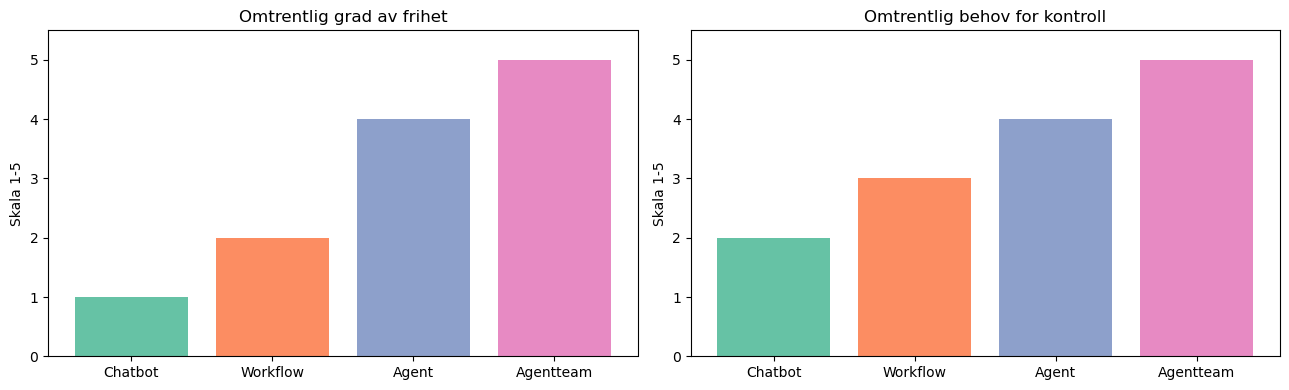

In [6]:
kategorier = ["Chatbot", "Workflow", "Agent", "Agentteam"]
frihet = [1, 2, 4, 5]
kontrollbehov = [2, 3, 4, 5]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

farger = ["#66c2a5", "#fc8d62", "#8da0cb", "#e78ac3"]

axes[0].bar(kategorier, frihet, color=farger)
axes[0].set_title("Omtrentlig grad av frihet")
axes[0].set_ylabel("Skala 1-5")
axes[0].set_ylim(0, 5.5)

axes[1].bar(kategorier, kontrollbehov, color=farger)
axes[1].set_title("Omtrentlig behov for kontroll")
axes[1].set_ylabel("Skala 1-5")
axes[1].set_ylim(0, 5.5)

plt.tight_layout()
plt.show()


**Tolkning:** De to panelene er bevisst ganske like. Poenget er å illustrere at når et AI-system får mer frihet til å velge steg, bruke verktøy og organisere arbeidet selv, øker også behovet for menneskelig kontroll, logging og tydelige rammer. Figuren er derfor en pedagogisk modell, ikke en presis måling.
